In [1]:
from utils import *
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


## Linear Regression

Simple population-level linear regression model. The country is not considered.

In [11]:
X, Y, C = load_height_data()
model = LinearRegression().fit(X, Y)
y_pred = model.predict(X)
print("Loss:\n", np.mean((y_pred - Y)**2))
print("RMSD:\n", np.sqrt(np.mean((y_pred - Y)**2)))

Loss:
 45.53098
RMSD:
 6.747665


Next, we try learning a separate linear regression model for each country. Notice the loss is much better.

In [12]:
X, Y, C = load_height_data()
model = ContextLinearRegression().fit(X, Y, C)
y_pred = model.predict(X, C)
print("Loss:\n", np.mean((y_pred - Y)**2))
print("RMSD:\n", np.sqrt(np.mean((y_pred - Y)**2)))

Loss:
 23.753902446756058
RMSD:
 4.87379753854795


## Multilayer Perceptron
The MLP without country as input performs about equally well as learning a separate linear regression model for each country.

In [13]:
model = NeuralNetwork(dim_in=3, dim_out=1, dim_hidden=300, n_hidden=1).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

full_dataset = HeightDataset()

training_data, test_data = torch.utils.data.random_split(full_dataset, [0.8, 0.2])
train_dataloader = DataLoader(training_data, batch_size=50)
test_dataloader = DataLoader(test_data, batch_size=50)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer, device)
    test_loss = test(test_dataloader, model, loss_fn, device)
print("Done!")

print("Loss:", test_loss.item())
print("RMSD:", np.sqrt(test_loss.item()))

Epoch 1
-------------------------------
loss: 429.734375  [   50/168000]
loss: 45.613056  [ 5050/168000]
loss: 36.979351  [10050/168000]
loss: 33.884598  [15050/168000]
loss: 30.421684  [20050/168000]
loss: 42.072632  [25050/168000]
loss: 30.206411  [30050/168000]
loss: 24.292603  [35050/168000]
loss: 35.281677  [40050/168000]
loss: 25.380932  [45050/168000]
loss: 20.511471  [50050/168000]
loss: 23.718784  [55050/168000]
loss: 24.024479  [60050/168000]
loss: 28.781427  [65050/168000]
loss: 25.895962  [70050/168000]
loss: 33.071774  [75050/168000]
loss: 23.801687  [80050/168000]
loss: 25.446751  [85050/168000]
loss: 22.715723  [90050/168000]
loss: 26.656013  [95050/168000]
loss: 24.727568  [100050/168000]
loss: 23.089285  [105050/168000]
loss: 33.215614  [110050/168000]
loss: 30.414629  [115050/168000]
loss: 25.867558  [120050/168000]
loss: 19.217968  [125050/168000]
loss: 23.195490  [130050/168000]
loss: 15.265806  [135050/168000]
loss: 28.481581  [140050/168000]
loss: 25.600704  [1450

## Context-Sensitive Network
The task is one-hot-encoded and appended to the input.

In [14]:
model = NeuralNetwork(dim_in=203, dim_out=1, dim_hidden=300, n_hidden=3).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

full_dataset = ContextSensitiveHeightDataset()

training_data, test_data = torch.utils.data.random_split(full_dataset, [0.8, 0.2])
train_dataloader = DataLoader(training_data, batch_size=50)
test_dataloader = DataLoader(test_data, batch_size=50)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer, device)
    test_loss = test(test_dataloader, model, loss_fn, device)
print("Done!")

print("Loss:", test_loss.item())
print("RMSD:", np.sqrt(test_loss.item()))

Epoch 1
-------------------------------
loss: 331.746307  [   50/168000]
loss: 40.781631  [ 5050/168000]
loss: 25.461664  [10050/168000]
loss: 40.032555  [15050/168000]
loss: 43.459724  [20050/168000]
loss: 34.916988  [25050/168000]
loss: 31.376133  [30050/168000]
loss: 31.249811  [35050/168000]
loss: 26.349007  [40050/168000]
loss: 29.113007  [45050/168000]
loss: 24.952339  [50050/168000]
loss: 22.770981  [55050/168000]
loss: 29.075806  [60050/168000]
loss: 23.920170  [65050/168000]
loss: 28.978153  [70050/168000]
loss: 23.888945  [75050/168000]
loss: 15.056357  [80050/168000]
loss: 23.623674  [85050/168000]
loss: 15.057790  [90050/168000]
loss: 17.082714  [95050/168000]
loss: 19.912663  [100050/168000]
loss: 18.221647  [105050/168000]
loss: 22.354872  [110050/168000]
loss: 18.768999  [115050/168000]
loss: 21.283648  [120050/168000]
loss: 18.665510  [125050/168000]
loss: 17.913023  [130050/168000]
loss: 19.501816  [135050/168000]
loss: 17.890760  [140050/168000]
loss: 18.838717  [1450

## Learned-Context Neural Network
Instead of one-hot encoding, the task is represented as a learned context parameter and appended to the input.

In [3]:
model = LearnedContextNN(dim_in=3, dim_out=1, dim_hidden=300, n_hidden=3, dim_context=30, n_context=200).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

full_dataset = ContextSensitiveHeightDataset()

training_data, test_data = torch.utils.data.random_split(full_dataset, [0.8, 0.2])
train_dataloader = DataLoader(training_data, batch_size=50)
test_dataloader = DataLoader(test_data, batch_size=50)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer, device)
    test_loss = test(test_dataloader, model, loss_fn, device)
print("Done!")

print("Loss:", test_loss.item())
print("RMSD:", np.sqrt(test_loss.item()))

Epoch 1
-------------------------------
loss: 361.046021  [   50/168000]
loss: 30.001230  [ 5050/168000]
loss: 36.133129  [10050/168000]
loss: 25.951054  [15050/168000]
loss: 24.040258  [20050/168000]
loss: 24.041294  [25050/168000]
loss: 32.219769  [30050/168000]
loss: 20.430801  [35050/168000]
loss: 23.104195  [40050/168000]
loss: 13.644760  [45050/168000]
loss: 15.912150  [50050/168000]
loss: 9.618295  [55050/168000]
loss: 8.372338  [60050/168000]
loss: 10.065187  [65050/168000]
loss: 9.260690  [70050/168000]
loss: 10.783900  [75050/168000]
loss: 4.434227  [80050/168000]
loss: 2.501760  [85050/168000]
loss: 3.199759  [90050/168000]
loss: 5.092778  [95050/168000]
loss: 4.658932  [100050/168000]
loss: 2.494370  [105050/168000]
loss: 8.040448  [110050/168000]
loss: 3.009257  [115050/168000]
loss: 1.914656  [120050/168000]
loss: 2.254064  [125050/168000]
loss: 3.730703  [130050/168000]
loss: 1.916394  [135050/168000]
loss: 2.196719  [140050/168000]
loss: 2.347542  [145050/168000]
loss: 

## What is the model learning?
Here, we extract the learned context parameters from the model and run PCA to visualize them in 2 dimensions. The context parameter appears to encode information about which countries have taller people on average. It is likely also learning latent patterns that aren't apparent at a glance.

In [12]:
context_params = model.get_parameter("context").cpu().detach().numpy()

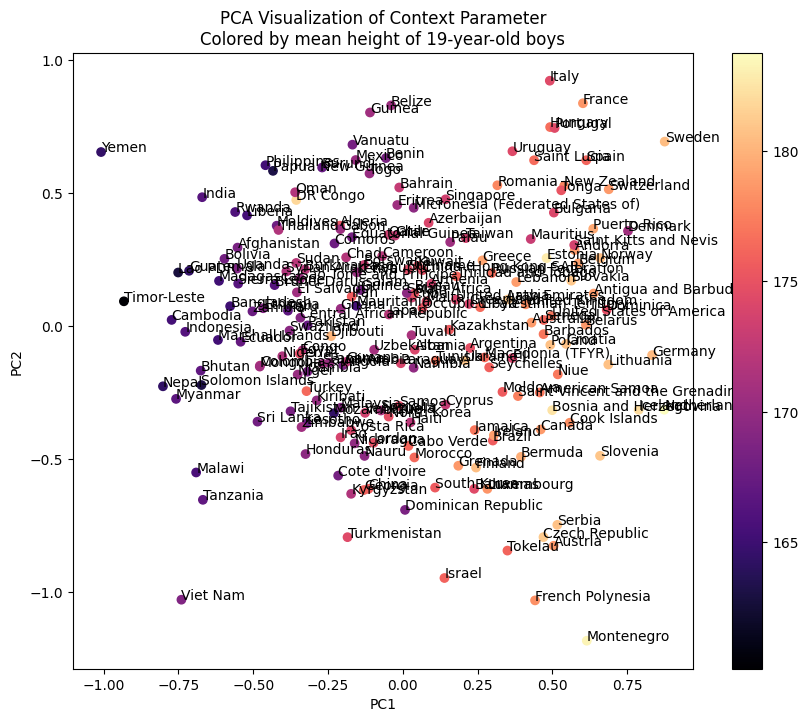

In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import polars as pl

df_orig = pl.read_csv("data/NCD_RisC_Lancet_2020_height_child_adolescent_country.csv")
df = df_orig.to_dummies(columns="Sex")
df = df.rename({"Sex_Boys": "Sex"})
df = df.with_columns(pl.col("Year").sub(1985).alias("Year_since_1985"))
df = df.select(["Country", "Sex", "Year_since_1985", "Age group", "Mean height"])
mean_height_19M = df.filter(df['Year_since_1985']==34, df['Age group']==19, df['Sex']==1)['Mean height']

pca = PCA(n_components=2)
reduced_features = pca.fit_transform(context_params)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=mean_height_19M, cmap='magma')
plt.colorbar()

labels=full_dataset.context_labels
for label, feature in zip(labels, reduced_features):
    plt.annotate(label, (feature[0], feature[1]))


plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Visualization of Context Parameter\nColored by mean height of 19-year-old boys')
plt.show()

# Using a one-dimensional context parameter
When we reduce the dimension of the context parameter to 1, the model performs worse (roughly equal to the performance of the context-sensitive network, which uses the one-hot encoding as input). We can still see that it encodes information about which countries have taller people on average.

In [41]:
model_1d_context = LearnedContextNN(dim_in=3, dim_out=1, dim_hidden=300, n_hidden=3, dim_context=1, n_context=200).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model_1d_context.parameters(), lr=1e-3)

full_dataset = ContextSensitiveHeightDataset()

training_data, test_data = torch.utils.data.random_split(full_dataset, [0.8, 0.2])
train_dataloader = DataLoader(training_data, batch_size=50)
test_dataloader = DataLoader(test_data, batch_size=50)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_1d_context, loss_fn, optimizer, device)
    test_loss = test(test_dataloader, model_1d_context, loss_fn, device)
print("Done!")

print("Loss:", test_loss.item())
print("RMSD:", np.sqrt(test_loss.item()))

Epoch 1
-------------------------------
loss: 456.866821  [   50/168000]
loss: 41.662586  [ 5050/168000]
loss: 37.985237  [10050/168000]
loss: 30.133368  [15050/168000]
loss: 31.695444  [20050/168000]
loss: 48.129364  [25050/168000]
loss: 26.095957  [30050/168000]
loss: 19.563770  [35050/168000]
loss: 31.120829  [40050/168000]
loss: 28.211079  [45050/168000]
loss: 24.261581  [50050/168000]
loss: 26.316776  [55050/168000]
loss: 21.725746  [60050/168000]
loss: 30.889616  [65050/168000]
loss: 45.061424  [70050/168000]
loss: 25.997221  [75050/168000]
loss: 26.252998  [80050/168000]
loss: 27.978247  [85050/168000]
loss: 22.902815  [90050/168000]
loss: 16.905352  [95050/168000]
loss: 24.861408  [100050/168000]
loss: 41.608467  [105050/168000]
loss: 21.814594  [110050/168000]
loss: 16.823299  [115050/168000]
loss: 23.425074  [120050/168000]
loss: 27.148354  [125050/168000]
loss: 31.293003  [130050/168000]
loss: 20.725624  [135050/168000]
loss: 15.587734  [140050/168000]
loss: 19.495451  [1450

In [47]:
model_1d_context.get_parameter("context").cpu().detach().numpy().flatten()


array([-0.12350762,  0.69452554,  0.37568915,  0.89607185,  0.9496959 ,
        0.12333987,  0.9384655 ,  0.6781766 ,  0.45394242,  0.9464129 ,
        1.1484131 ,  0.41318846,  0.75607485,  0.4986905 , -0.09414741,
        0.9539523 ,  0.9244287 ,  1.1455595 ,  0.46985894,  0.19571567,
        0.95494235, -0.03586694,  0.24999696,  1.0764626 ,  0.40452102,
        0.6524748 ,  0.11236962,  0.6942481 ,  0.23326756, -0.01156315,
        0.39821962, -0.17001812,  0.22925428,  0.91747177,  0.18259764,
        0.30170912,  0.63159466,  0.4774163 ,  0.40146318,  0.2713819 ,
        0.11142509,  0.18480507,  1.0563056 ,  0.5443403 ,  0.2906041 ,
        1.2310734 ,  0.5663165 ,  0.71423745,  1.0761962 ,  0.01073234,
        1.1145815 ,  0.33196813,  1.0048298 ,  0.6119673 ,  0.06667636,
        0.16600181,  0.14126107,  0.12674865,  0.26561219,  1.1324239 ,
       -0.07493623,  0.7470054 ,  1.0062023 ,  0.9294316 ,  1.2030504 ,
        0.313692  ,  0.2774151 ,  0.5226974 ,  1.0876367 ,  0.15

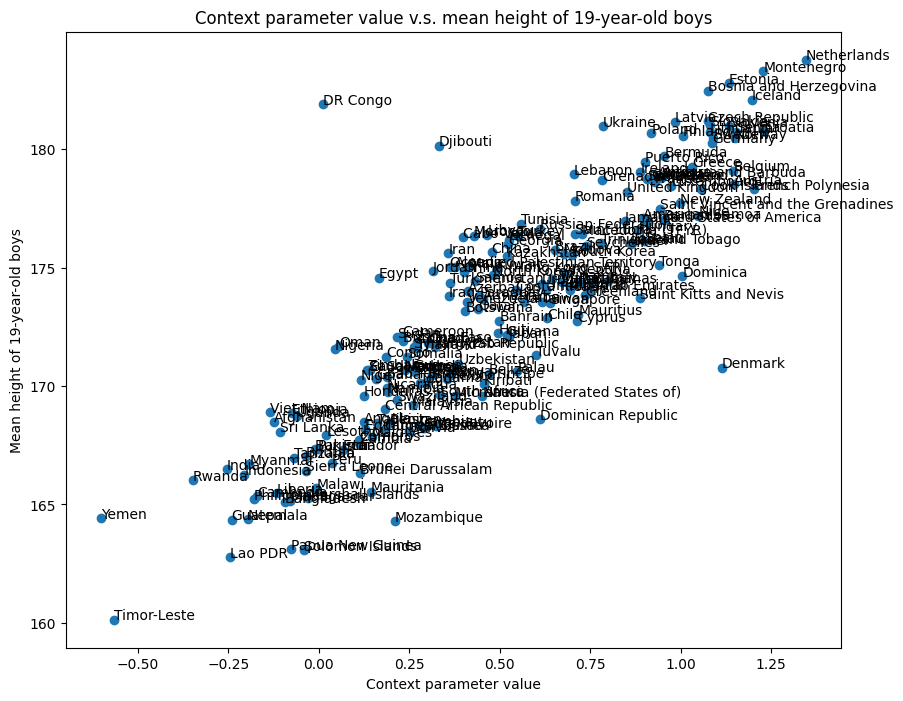

In [50]:
context_params_1d_context = model_1d_context.get_parameter("context").cpu().detach().numpy()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(context_params_1d_context, mean_height_19M)

labels=full_dataset.context_labels
for i in range(len(labels)):
    plt.annotate(labels[i], (context_params_1d_context.flatten()[i], mean_height_19M[i]))

plt.xlabel('Context parameter value')
plt.ylabel('Mean height of 19-year-old boys')
plt.title('Context parameter value v.s. mean height of 19-year-old boys')
plt.show()